In [1]:
#Karthick N
#24BAD055
#importing librairies
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import StackingClassifier

import matplotlib.pyplot as plt

In [2]:
#Loading the dataset
df = pd.read_csv("heart_stacking.csv")
print(df.head())

   Age  Cholesterol  MaxHeartRate  RestingBP  HeartDisease
0   57          212           189        118             0
1   44          266           155        146             1
2   59          279           168        128             1
3   66          237           123        145             1
4   58          221           125        132             0


In [3]:
# Splitting the dataset into features and target variable
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)   

In [4]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

# SVM
svm = SVC(probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)

# Decision Tree
dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

print("LR:", acc_lr)
print("SVM:", acc_svm)
print("DT:", acc_dt)

LR: 0.8333333333333334
SVM: 0.8055555555555556
DT: 0.9444444444444444


In [5]:
# Stacking Classifier
estimators = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('svm', SVC(probability=True)),
    ('dt', DecisionTreeClassifier(max_depth=5))
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

stack.fit(X_train, y_train)

y_pred_stack = stack.predict(X_test)
acc_stack = accuracy_score(y_test, y_pred_stack)

print("Stacking Accuracy:", acc_stack)

Stacking Accuracy: 0.9444444444444444


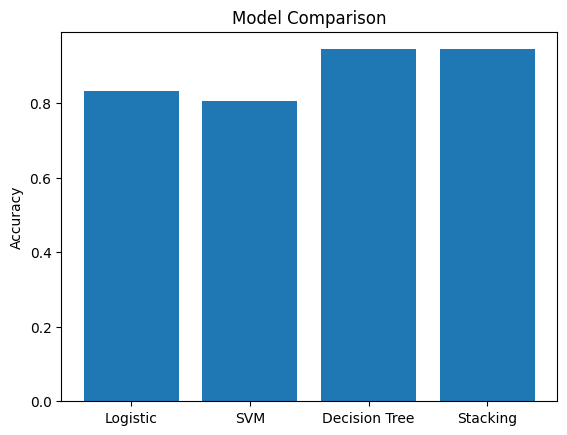

In [6]:
# Plotting the results
models = ["Logistic", "SVM", "Decision Tree", "Stacking"]
accuracies = [acc_lr, acc_svm, acc_dt, acc_stack]

plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()